# Final Project Pipeline — Full Audio Single-Transfer Version

This notebook is the **full-audio, single-transfer** version of the packed AXI-Stream pipeline.

## Important assumption
This notebook is for our shifted HLS core that has been updated from a fixed 1024-sample loop to a **TLAST-driven stream loop**:

```cpp
while (true) {
    axis_in_t in_val = in_stream.read();
    ...
    out_val.last = in_val.last;
    out_stream.write(out_val);
    if (in_val.last) break;
}
```

## What this notebook does
1. Load the full `.wav` file
2. Convert to mono and normalize
3. Generate a full-length carrier in software
4. Modulate the full signal in software
5. Pack `(modulated_sample, carrier_sample)` into one 64-bit AXI word
6. Send the **entire audio signal** to the FPGA in one DMA transfer
7. Receive the multiplied result back from the FPGA
8. Low-pass filter in software to recover the audio
9. Compare hardware vs software results
10. Visualize and play the original, encrypted, and decrypted signals

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
from pynq import Overlay, allocate
from scipy.io import wavfile
from IPython.display import Audio, display

plt.rcParams["figure.figsize"] = (12, 4)
np.set_printoptions(suppress=True, precision=4)

## Configuration

In [2]:
BITSTREAM_PATH = "/home/xilinx/jupyter_notebooks/final_project/demodulate_packed.bit"
WAV_PATH = "/home/xilinx/jupyter_notebooks/final_project/input.wav"

DMA_NAME = "axi_dma"
IP_NAME = "demodulate_packed_0"

CARRIER_FREQ_HZ = 4000
LPF_CUTOFF_HZ = 2000

PRINT_IP_INFO = True
PLOT_SAMPLES = 4000
SAVE_PREFIX = "/home/xilinx/jupyter_notebooks/final_project"

## Helper functions

In [3]:
def normalize_audio(x):
    x = np.asarray(x, dtype=np.float32)
    peak = np.max(np.abs(x))
    if peak == 0:
        return x
    return x / peak

def pack_signal_and_carrier(signal_f32, carrier_f32):
    signal_f32 = np.asarray(signal_f32, dtype=np.float32)
    carrier_f32 = np.asarray(carrier_f32, dtype=np.float32)

    sig_u32 = signal_f32.view(np.uint32)
    car_u32 = carrier_f32.view(np.uint32)

    packed_u64 = (car_u32.astype(np.uint64) << 32) | sig_u32.astype(np.uint64)
    return packed_u64

def lowpass_fft(signal, sample_rate, cutoff_hz):
    spectrum = np.fft.rfft(signal)
    freqs = np.fft.rfftfreq(len(signal), d=1 / sample_rate)
    spectrum[freqs > cutoff_hz] = 0
    filtered = np.fft.irfft(spectrum, n=len(signal))
    return filtered.astype(np.float32)

def make_time_axis(num_samples, sample_rate):
    return np.arange(num_samples) / sample_rate

def save_wav_float(path, sample_rate, audio_float):
    audio_float = normalize_audio(audio_float)
    audio_int16 = np.int16(np.clip(audio_float, -1.0, 1.0) * 32767)
    wavfile.write(path, sample_rate, audio_int16)

## Load overlay

In [4]:
ol = Overlay(BITSTREAM_PATH)

if PRINT_IP_INFO:
    print("IP blocks:", list(ol.ip_dict.keys()))

dma = getattr(ol, DMA_NAME)
ip = getattr(ol, IP_NAME)

IP blocks: ['demodulate_packed_0', 'axi_dma', 'zynq_ultra_ps_e_0']


## Load full audio

In [5]:
rate, audio = wavfile.read(WAV_PATH)

if audio.ndim == 2:
    audio = audio.mean(axis=1)

audio = audio.astype(np.float32)
audio = normalize_audio(audio)

N = len(audio)
t = np.arange(N) / rate
carrier = np.cos(2 * np.pi * CARRIER_FREQ_HZ * t).astype(np.float32)

print("Sample rate:", rate)
print("Number of samples:", N)
print("Duration (s):", N / rate)
print("First 10 original samples:", audio[:10])

Sample rate: 8000
Number of samples: 23493
Duration (s): 2.936625
First 10 original samples: [ 0.0011  0.0011  0.0011  0.      0.      0.0011  0.     -0.0011  0.
 -0.0011]


## Visualize and listen to the original full audio

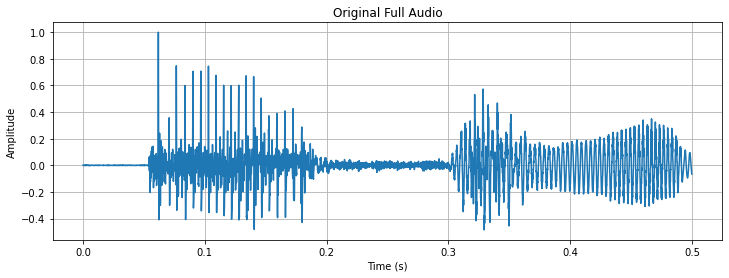

In [6]:
plot_n = min(PLOT_SAMPLES, N)
time_axis_plot = make_time_axis(plot_n, rate)

plt.figure()
plt.plot(time_axis_plot, audio[:plot_n])
plt.title("Original Full Audio")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

display(Audio(audio, rate=rate))

## Modulate full audio in software

In [7]:
modulated = audio * carrier

print("First 10 modulated samples:", modulated[:10])

First 10 modulated samples: [ 0.0011 -0.0011  0.0011 -0.      0.     -0.0011  0.      0.0011  0.
  0.0011]


## Visualize and listen to the encrypted/modulated audio

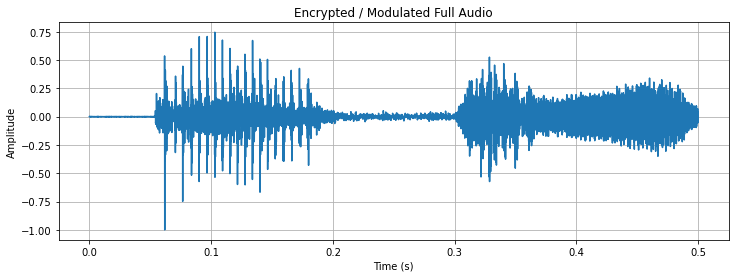

In [8]:
plt.figure()
plt.plot(time_axis_plot, modulated[:plot_n])
plt.title("Encrypted / Modulated Full Audio")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

display(Audio(modulated, rate=rate))

## Pack full signal for DMA

In [9]:
packed_input = pack_signal_and_carrier(modulated, carrier)

print("Packed input dtype:", packed_input.dtype)
print("Packed input shape:", packed_input.shape)
print("First 5 packed words:", packed_input[:5])

Packed input dtype: uint64
Packed input shape: (23493,)
First 5 packed words: [ 4575657222391269303 13799029261393528759  4575657222391269303
 13799029260410683392  4575657221408423936]


## Allocate full-length DMA buffers

This version sends the **entire audio signal** in one DMA transaction.

In [10]:
in_buffer = allocate(shape=(N,), dtype=np.uint64)
out_buffer = allocate(shape=(N,), dtype=np.float32)

in_buffer[:] = packed_input
out_buffer[:] = 0.0

in_buffer.flush()
out_buffer.flush()

## Run FPGA over the full signal

In [12]:
print("Starting full-audio hardware execution...")
start_hw = time.perf_counter()

dma.recvchannel.transfer(out_buffer)
ip.write(0x00, 0x01)
dma.sendchannel.transfer(in_buffer)

dma.sendchannel.wait()
dma.recvchannel.wait()

end_hw = time.perf_counter()

out_buffer.invalidate()
mixed_back_hw = np.copy(out_buffer)

print(f"Hardware finished successfully in {end_hw - start_hw:.6f} seconds")
print("First 10 mixed_back_hw samples:", mixed_back_hw[:10])
print("Hardware throughput (samples/s):", N / (end_hw - start_hw))

Starting full-audio hardware execution...
Hardware finished successfully in 0.001746 seconds
First 10 mixed_back_hw samples: [ 0.0011  0.0011  0.0011  0.      0.      0.0011  0.     -0.0011  0.
 -0.0011]
Hardware throughput (samples/s): 13454632.9228305


## Software reference for multiply

In [13]:
start_sw = time.perf_counter()
mixed_back_sw = modulated * carrier
end_sw = time.perf_counter()

print(f"Software multiply time: {end_sw - start_sw:.6f} seconds")
print("Software throughput (samples/s):", N / (end_sw - start_sw))

mse_mult = np.mean((mixed_back_sw - mixed_back_hw) ** 2)
max_err_mult = np.max(np.abs(mixed_back_sw - mixed_back_hw))

print("Multiply-stage MSE:", mse_mult)
print("Multiply-stage Max err:", max_err_mult)

Software multiply time: 0.000588 seconds
Software throughput (samples/s): 39947899.21985871
Multiply-stage MSE: 0.0
Multiply-stage Max err: 0.0


## Recover audio with low-pass filtering

In [14]:
demod_hw = 2.0 * lowpass_fft(mixed_back_hw, rate, LPF_CUTOFF_HZ)
demod_sw = 2.0 * lowpass_fft(mixed_back_sw, rate, LPF_CUTOFF_HZ)

demod_hw = normalize_audio(demod_hw)
demod_sw = normalize_audio(demod_sw)
audio_ref = normalize_audio(audio)

print("First 10 recovered HW samples:", demod_hw[:10])
print("First 10 recovered SW samples:", demod_sw[:10])

First 10 recovered HW samples: [ 0.002   0.0025  0.0003 -0.0006  0.0011  0.0015 -0.0005 -0.0015 -0.0004
 -0.0002]
First 10 recovered SW samples: [ 0.002   0.0025  0.0003 -0.0006  0.0011  0.0015 -0.0005 -0.0015 -0.0004
 -0.0002]


## Compare recovered outputs

In [15]:
mse_recovered = np.mean((demod_hw - demod_sw) ** 2)
max_err_recovered = np.max(np.abs(demod_hw - demod_sw))

print("Recovered-signal MSE:", mse_recovered)
print("Recovered-signal Max err:", max_err_recovered)

Recovered-signal MSE: 0.0
Recovered-signal Max err: 0.0


## Visualize original vs encrypted vs decrypted

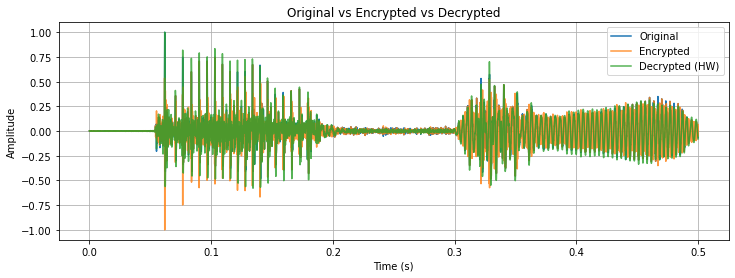

In [16]:
plt.figure()
plt.plot(time_axis_plot, audio_ref[:plot_n], label="Original")
plt.plot(time_axis_plot, modulated[:plot_n], label="Encrypted", alpha=0.8)
plt.plot(time_axis_plot, demod_hw[:plot_n], label="Decrypted (HW)", alpha=0.8)
plt.title("Original vs Encrypted vs Decrypted")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

## Visualize decrypted hardware vs software

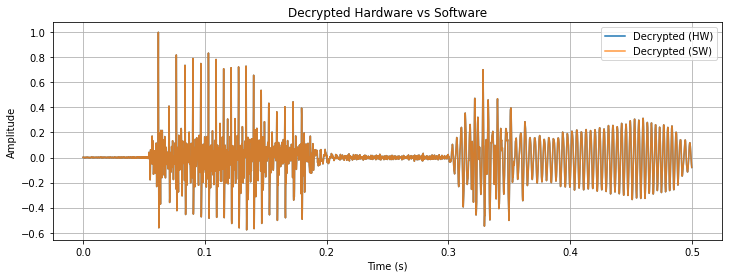

In [17]:
plt.figure()
plt.plot(time_axis_plot, demod_hw[:plot_n], label="Decrypted (HW)")
plt.plot(time_axis_plot, demod_sw[:plot_n], label="Decrypted (SW)", alpha=0.8)
plt.title("Decrypted Hardware vs Software")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

## Listen to full-audio results

In [18]:
print("Original full audio:")
display(Audio(audio_ref, rate=rate))

print("Encrypted / modulated full audio:")
display(Audio(modulated, rate=rate))

print("Decrypted hardware full audio:")
display(Audio(demod_hw, rate=rate))

print("Decrypted software full audio:")
display(Audio(demod_sw, rate=rate))

Original full audio:


Encrypted / modulated full audio:


Decrypted hardware full audio:


Decrypted software full audio:


## Save output WAV files

In [19]:
save_wav_float(f"{SAVE_PREFIX}/encrypted_modulated_full.wav", rate, modulated)
save_wav_float(f"{SAVE_PREFIX}/recovered_hw_full.wav", rate, demod_hw)
save_wav_float(f"{SAVE_PREFIX}/recovered_sw_full.wav", rate, demod_sw)

print("Saved:")
print(f"{SAVE_PREFIX}/encrypted_modulated_full.wav")
print(f"{SAVE_PREFIX}/recovered_hw_full.wav")
print(f"{SAVE_PREFIX}/recovered_sw_full.wav")

Saved:
/home/xilinx/jupyter_notebooks/final_project/encrypted_modulated_full.wav
/home/xilinx/jupyter_notebooks/final_project/recovered_hw_full.wav
/home/xilinx/jupyter_notebooks/final_project/recovered_sw_full.wav


## Cleanup

In [20]:
in_buffer.close()
out_buffer.close()
print("Buffers closed.")

Buffers closed.
